# 🏀 NBA MVP Prediction Model

In this model, I use maching learning to predict the NBA MVP voting shares from 2000-2024 using player and team performance data. This model utilizes a Random Forest Regressor and achieves an R² value of 0.83, accurately identifying MVP-level performances over the course of a season.

### Data Sources:

- Player Stats - NBA API
- MVP Voting Shares - Basketball Reference
- Advanced Stats - Basketball Reference

## 1. Data Loading and Cleaning:

In [60]:
import pandas as pd

all_df = pd.read_csv("all_data.csv")

# Check final dataset
all_df.info()
all_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9095 entries, 0 to 9094
Data columns (total 35 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PLAYER_NAME    9095 non-null   object 
 1   GP             9095 non-null   int64  
 2   PLAYER_W_PCT   9095 non-null   float64
 3   MIN            9095 non-null   float64
 4   FGA            9095 non-null   float64
 5   FG_PCT         9095 non-null   float64
 6   FG3A           9095 non-null   float64
 7   FG3_PCT        9095 non-null   float64
 8   FTA            9095 non-null   float64
 9   FT_PCT         9095 non-null   float64
 10  REB            9095 non-null   float64
 11  AST            9095 non-null   float64
 12  STL            9095 non-null   float64
 13  BLK            9095 non-null   float64
 14  PTS            9095 non-null   float64
 15  PLUS_MINUS     9095 non-null   float64
 16  SEASON         9095 non-null   object 
 17  TEAM_NAME      9095 non-null   object 
 18  TEAM_W_P

,PLAYER_NAME,GP,PLAYER_W_PCT,MIN,FGA,FG_PCT,FG3A,FG3_PCT,FTA,FT_PCT,...,OBPM,DBPM,BPM,VORP,PTS_PER_MIN,AST_PER_MIN,REB_PER_MIN,FG_MISS,FT_MISS,EFFICIENCY
0,A.C. Green,82,0.610,17.2,4.0,0.444,0.1,0.000,1.4,0.712,...,-2.2,0.0,-2.2,-0.1,0.261628,0.029070,0.220930,2.2240,0.4032,6.1728
1,A.J. Guyton,33,0.182,19.0,5.8,0.406,2.1,0.391,0.5,0.833,...,-0.8,-3.2,-4.0,-0.3,0.315789,0.100000,0.057895,3.4452,0.0835,5.2713
2,Aaron McKie,76,0.671,31.5,9.4,0.473,2.2,0.312,2.6,0.768,...,0.1,1.3,1.4,2.1,0.368254,0.158730,0.130159,4.9538,0.6032,13.9430
3,Aaron Williams,82,0.317,28.5,7.9,0.457,0.0,0.000,3.8,0.787,...,-1.3,-0.3,-1.6,0.2,0.357895,0.038596,0.252632,4.2897,0.8094,13.9009
4,Adonal Foyle,58,0.138,25.2,6.5,0.416,0.0,0.000,1.2,0.441,...,-3.6,0.8,-2.8,-0.3,0.234127,0.031746,0.277778,3.7960,0.6708,11.0332


We have 9,095 observations, each one being a player in a specific season between 2000 and 2024. There are a total of 35 features across the 25 seasons.

## 3. Model Setup

In [61]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

features = ["GP",
            "MIN",
            "PTS",
            "PTS_PER_MIN",
            "AST",
            "AST_PER_MIN",
            "REB",
            "REB_PER_MIN",
            "FGA", 
            "FG_PCT", 
            "FG3A", 
            "FG3_PCT", 
            "FTA", 
            "FT_PCT",
            "STL",
            "BLK",
            "EFFICIENCY",
            "PLUS_MINUS", 
            "TEAM_W_PCT",
            "PER",
            "TS%",
            "USG%",
            "WS",
            "WS/48",
            "OBPM",
            "DBPM",
            "BPM",
            "VORP"]

X = all_df[features]
y = all_df["MVP_PCT_SHARE"]

# Manually creating train/test split because player data must be kept within season for meaningful training
train = all_df[all_df["SEASON"] < "2020-21"]
test  = all_df[all_df["SEASON"] >= "2020-21"]

X_train = train[features]
y_train = train["MVP_PCT_SHARE"]
X_test  = test[features]
y_test  = test["MVP_PCT_SHARE"]


model = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=5, random_state=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Model R²: ", r2_score(y_true=y_test, y_pred=y_pred))
print("Model RMSE: ", np.sqrt(mean_squared_error(y_true=y_test, y_pred=y_pred)))

Model R²:  0.8346524590401321
Model RMSE:  0.025909376393538568


The random forests model is able to capture non-linear relationships of stats that are relevant to MVP voting shares. With an R² value of 0.82, the model explains about 82% of variation in MVP voting outcomes.

## 4. Model Evaluation

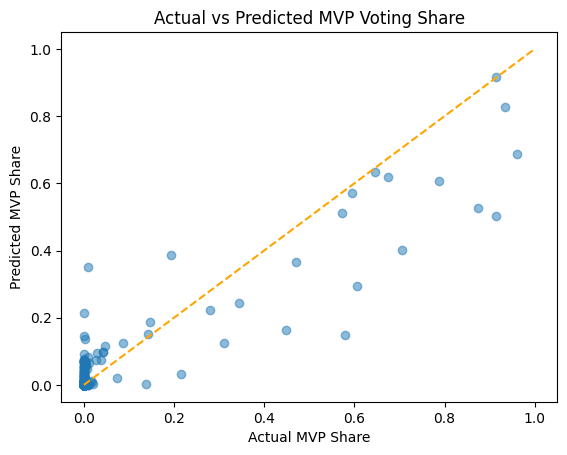

In [62]:
import matplotlib.pyplot as plt

# Graph the actual MVP share vs the model prediction
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual MVP Share")
plt.ylabel("Predicted MVP Share")
plt.title("Actual vs Predicted MVP Voting Share")
plt.plot([0, 1], [0, 1], "--", color="orange")
plt.show()

This model performs well as it predicts MVP voting shares close to their true values across multiple seasons.

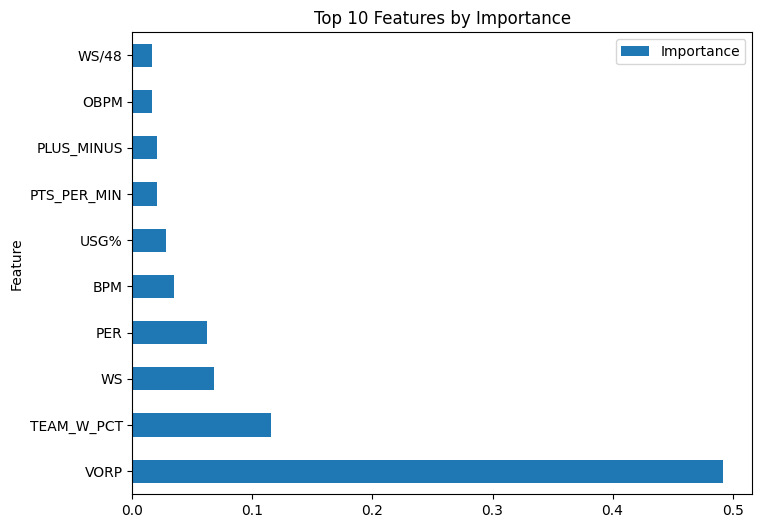

In [63]:
# Create a data frame of features and their importance in the model's prediction 
importances = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

# Graph the 10 most important features
importances.head(10).plot.barh(x="Feature", y="Importance", figsize=(8,6))
plt.title("Top 10 Features by Importance")
plt.show()

Efficiency, team win percentage, and points scored are the most importnat features in this model.

## 5. Predicted MVPs each season
Below are the top predicted NBA MVP candidates for each season

In [64]:
all_df["PREDICTED_SHARE"] = model.predict(X)
all_df.groupby("SEASON").apply(lambda s: s.sort_values("PREDICTED_SHARE", ascending=False).head(5))[["PLAYER_NAME", "PREDICTED_SHARE"]]

/var/folders/xj/8cpqrj296ps437ph0z5g80_80000gn/T/ipykernel_22287/95824214.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  all_df.groupby("SEASON").apply(lambda s: s.sort_values("PREDICTED_SHARE", ascending=False).head(5))[["PLAYER_NAME", "PREDICTED_SHARE"]]


PLAYER_NAME  PREDICTED_SHARE
SEASON                                                
2000-01 8               Allen Iverson         0.552125
        277          Shaquille O'Neal         0.535659
        293                Tim Duncan         0.315699
        60               Chris Webber         0.261871
        185               Kobe Bryant         0.157197
...                               ...              ...
2024-25 9045  Shai Gilgeous-Alexander         0.917214
        9003             Nikola Jokić         0.608153
        8825    Giannis Antetokounmpo         0.364860
        8876             Jayson Tatum         0.123508
        8965              Luka Dončić         0.072058

[125 rows x 2 columns]

## 6. Insights
- Interaction terms are key for predictions (Ex: High point scorers on high-win teams)
- Advanced and per-minute stats help for comparison between starters and non-starters

## 7. Conclusion
This project demonstrates how non-linear relationships between player statistics as well as team performance are key in predicting the NBA MVP voting outcomes. An R² value of 0.83 displays that this model can effectively identify MVP-level performances from players and quantify them in terms of MVP voting. 

### 🚀 Next Steps
- Build a Streamlit app for live MVP leaderboard predictions